<a href="https://colab.research.google.com/github/SaimNaveed646/ML_Models/blob/main/Pandas/Case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

Pandas is a Python library used for data manipulation and analysis.
It is designed for working with structured data, meaning rows and columns—just like a table in Excel or a database.
Almost every machine learning project uses Pandas at the data preprocessing stage.


# **Series**

Series is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index. The basic method to create a Series is to cal

In [ ]:
s = pd.Series([10,20,30,40,50])
s

,0
0,10
1,20
2,30
3,40
4,50


In [ ]:
s = pd.Series([1,2,3,4,5], index=["a", "b", "c", "d", "e"])
s

,0
a,1
b,2
c,3
d,4
e,5


# **Dataframe**

DataFrame is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it like a spreadsheet or SQL table, or a dict of Series objects. It is generally the most commonly used pandas object. Like Series, DataFrame accepts many different kinds of input

In [ ]:
data = {
    "Name": ["Ali", "Sara", "Ahmed"],
    "Age": [20, 22, 21],
    "CGPA": [3.2, 3.8, 3.5]
}


In [ ]:
df = pd.DataFrame(data)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    3 non-null      object 
 1   Age     3 non-null      int64  
 2   CGPA    3 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 204.0+ bytes
None


# Case study using pandas

Case Study: Online Store Sales Analysis using Pandas

You are hired as a data analyst for an online retail store.
Management wants to understand:

* Which products and categories generate the most revenue

* Monthly sales trends

* City-wise performance

* Low-performing products

# Load and Explore Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/QCRI Project/test.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        11 non-null     int64 
 1   order_date      11 non-null     object
 2   product         11 non-null     object
 3   category        10 non-null     object
 4   price           11 non-null     int64 
 5   quantity        11 non-null     int64 
 6   city            11 non-null     object
 7   payment_method  11 non-null     object
dtypes: int64(3), object(5)
memory usage: 836.0+ bytes


In [ ]:
df.head()

,order_id,order_date,product,category,price,quantity,city,payment_method
0,1001,2024-01-05,Laptop,NaN,120000,1,Karachi,Credit Card
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,Lahore,Cash on Delivery
2,1003,2024-01-07,Headphones,Accessories,5000,3,Islamabad,Debit Card
3,1004,2024-01-10,Office Chair,Furniture,25000,1,khi,Credit Card
4,1005,2024-02-02,Laptop,Electronics,120000,1,Lahore,Credit Card


In [ ]:
df.shape

(11, 8)

In [ ]:
df['category'].unique()



array(['Electronics', 'Accessories', 'Furniture'], dtype=object)

In [ ]:
df.dtypes

,0
order_id,int64
order_date,object
product,object
category,object
price,int64
quantity,int64
city,object
payment_method,object


In [ ]:
df.describe()

,order_id,price,quantity
count,10.00000,10.000000,10.000000
mean,1005.50000,46800.000000,1.800000
std,3.02765,43819.833156,1.032796
min,1001.00000,3000.000000,1.000000
25%,1003.25000,10000.000000,1.000000
50%,1005.50000,35000.000000,1.500000
75%,1007.75000,60000.000000,2.000000
max,1010.00000,120000.000000,4.000000


# Data Cleaning & Feature Engineering

# Handling Missing Values

Some orders have missing city or payment method.
Detect missing values
Decide when to drop vs fill

In [ ]:
df.isna().sum()



,0
order_id,0
order_date,0
product,0
category,1
price,0
quantity,0
city,0
payment_method,0


In [ ]:
df[df['category'].isna()]


,order_id,order_date,product,category,price,quantity,city,payment_method
0,1001,2024-01-05,Laptop,NaN,120000,1,Karachi,Credit Card


In [ ]:
df.loc[df['category'].isna()]

,order_id,order_date,product,category,price,quantity,city,payment_method
0,1001,2024-01-05,Laptop,NaN,120000,1,Karachi,Credit Card


In [ ]:
df.loc[0, 'category'] = 'Electronics'


In [ ]:
# df.dropna()
# df['payment_method'].fillna('Unknown', inplace=True)

# Removing Duplicate Records

Same order exported twice.

In [ ]:
df.duplicated().sum()



np.int64(1)

In [ ]:
df = df.drop_duplicates()

# Fixing Inconsistent Text Data

Same city written differently

In [ ]:
df.tail()

,order_id,order_date,product,category,price,quantity,city,payment_method
5,1006,2024-02-05,Desk,Furniture,40000,1,Islamabad,Cash on Delivery
6,1007,2024-02-15,Mobile Phone,Electronics,60000,1,Karachi,Debit Card
7,1008,2024-03-01,Monitor,Electronics,30000,2,Lahore,Credit Card
8,1009,2024-03-05,Headphones,Accessories,5000,4,KARACHI,Cash on Delivery
9,1010,2024-03-10,Desk Lamp,Accessories,3000,2,Islamabad,Debit Card


Removes leading and trailing spaces from each string

In [ ]:
df['city'] = df['city'].str.lower().str.strip()

df.tail()

,order_id,order_date,product,category,price,quantity,city,payment_method
5,1006,2024-02-05,Desk,Furniture,40000,1,islamabad,Cash on Delivery
6,1007,2024-02-15,Mobile Phone,Electronics,60000,1,karachi,Debit Card
7,1008,2024-03-01,Monitor,Electronics,30000,2,lahore,Credit Card
8,1009,2024-03-05,Headphones,Accessories,5000,4,karachi,Cash on Delivery
9,1010,2024-03-10,Desk Lamp,Accessories,3000,2,islamabad,Debit Card


In [ ]:
df.head(20)

,order_id,order_date,product,category,price,quantity,city,payment_method
0,1001,2024-01-05,Laptop,Electronics,120000,1,karachi,Credit Card
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,lahore,Cash on Delivery
2,1003,2024-01-07,Headphones,Accessories,5000,3,islamabad,Debit Card
3,1004,2024-01-10,Office Chair,Furniture,25000,1,khi,Credit Card
4,1005,2024-02-02,Laptop,Electronics,120000,1,lahore,Credit Card
5,1006,2024-02-05,Desk,Furniture,40000,1,islamabad,Cash on Delivery
6,1007,2024-02-15,Mobile Phone,Electronics,60000,1,karachi,Debit Card
7,1008,2024-03-01,Monitor,Electronics,30000,2,lahore,Credit Card
8,1009,2024-03-05,Headphones,Accessories,5000,4,karachi,Cash on Delivery
9,1010,2024-03-10,Desk Lamp,Accessories,3000,2,islamabad,Debit Card


In [ ]:
df['city'] = df['city'].replace({'khi': 'karachi'})

In [ ]:
df.head(20)

,order_id,order_date,product,category,price,quantity,city,payment_method
0,1001,2024-01-05,Laptop,Electronics,120000,1,karachi,Credit Card
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,lahore,Cash on Delivery
2,1003,2024-01-07,Headphones,Accessories,5000,3,islamabad,Debit Card
3,1004,2024-01-10,Office Chair,Furniture,25000,1,karachi,Credit Card
4,1005,2024-02-02,Laptop,Electronics,120000,1,lahore,Credit Card
5,1006,2024-02-05,Desk,Furniture,40000,1,islamabad,Cash on Delivery
6,1007,2024-02-15,Mobile Phone,Electronics,60000,1,karachi,Debit Card
7,1008,2024-03-01,Monitor,Electronics,30000,2,lahore,Credit Card
8,1009,2024-03-05,Headphones,Accessories,5000,4,karachi,Cash on Delivery
9,1010,2024-03-10,Desk Lamp,Accessories,3000,2,islamabad,Debit Card


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

# Data Type Corrections

In [ ]:
# df['price'] = df['price'].astype(float)


Price imported as string. Mathematical operations fail silently

# Outlier Detection

Scenario: A product sold at 1,000,000 by mistake.

Returns a new DataFrame containing only rows where price > 300000

In [ ]:
df[df['price'] > 300000]
# df['price'] > 300000

,order_id,order_date,product,category,price,quantity,city,payment_method,total_sales,sales_category,discount,final_sales,month,weekday


Outliers ≠ errors always

Context matters

# 🔹 B. Feature Engineering (Business Intelligence)
6️⃣ Revenue Buckets

Create sales categories.

In [ ]:
df['total_sales'] = df['price'] * df['quantity']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10 non-null     int64         
 1   order_date      10 non-null     datetime64[ns]
 2   product         10 non-null     object        
 3   category        10 non-null     object        
 4   price           10 non-null     int64         
 5   quantity        10 non-null     int64         
 6   city            10 non-null     object        
 7   payment_method  10 non-null     object        
 8   total_sales     10 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.1+ KB


pd.cut() is a very powerful pandas function used for converting continuous numeric data into discrete bins or categories

In [ ]:
df['sales_category'] = pd.cut(
    df['total_sales'],
    bins=[0, 20000, 50000, 100000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)


used for customer segmentation

In [ ]:
df.head(20)

,order_id,order_date,product,category,price,quantity,city,payment_method,total_sales,sales_category
0,1001,2024-01-05,Laptop,Electronics,120000,1,karachi,Credit Card,120000,Very High
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,lahore,Cash on Delivery,120000,Very High
2,1003,2024-01-07,Headphones,Accessories,5000,3,islamabad,Debit Card,15000,Low
3,1004,2024-01-10,Office Chair,Furniture,25000,1,karachi,Credit Card,25000,Medium
4,1005,2024-02-02,Laptop,Electronics,120000,1,lahore,Credit Card,120000,Very High
5,1006,2024-02-05,Desk,Furniture,40000,1,islamabad,Cash on Delivery,40000,Medium
6,1007,2024-02-15,Mobile Phone,Electronics,60000,1,karachi,Debit Card,60000,High
7,1008,2024-03-01,Monitor,Electronics,30000,2,lahore,Credit Card,60000,High
8,1009,2024-03-05,Headphones,Accessories,5000,4,karachi,Cash on Delivery,20000,Low
9,1010,2024-03-10,Desk Lamp,Accessories,3000,2,islamabad,Debit Card,6000,Low


# 7️⃣ Discounted Sales Feature

Add discounts based on category.

.map() replaces each value in the column according to a mapping dictionary (or a function).

In [ ]:
df['discount'] = df['category'].map({
    'Electronics': 0.05,
    'Furniture': 0.10,
    'Accessories': 0.15
})

df['final_sales'] = df['total_sales'] * (1 - df['discount'])


In [ ]:
df.head()

,order_id,order_date,product,category,price,quantity,city,payment_method,total_sales,sales_category,discount,final_sales
0,1001,2024-01-05,Laptop,Electronics,120000,1,karachi,Credit Card,120000,Very High,0.05,114000.0
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,lahore,Cash on Delivery,120000,Very High,0.05,114000.0
2,1003,2024-01-07,Headphones,Accessories,5000,3,islamabad,Debit Card,15000,Low,0.15,12750.0
3,1004,2024-01-10,Office Chair,Furniture,25000,1,karachi,Credit Card,25000,Medium,0.10,22500.0
4,1005,2024-02-02,Laptop,Electronics,120000,1,lahore,Credit Card,120000,Very High,0.05,114000.0


# Order Month, Day, Weekday

Extract temporal features.

In [ ]:
df['month'] = df['order_date'].dt.month
df['weekday'] = df['order_date'].dt.day_name()


In [ ]:
df.head()

,order_id,order_date,product,category,price,quantity,city,payment_method,total_sales,sales_category,discount,final_sales,month,weekday
0,1001,2024-01-05,Laptop,Electronics,120000,1,karachi,Credit Card,120000,Very High,0.05,114000.0,1,Friday
1,1002,2024-01-06,Mobile Phone,Electronics,60000,2,lahore,Cash on Delivery,120000,Very High,0.05,114000.0,1,Saturday
2,1003,2024-01-07,Headphones,Accessories,5000,3,islamabad,Debit Card,15000,Low,0.15,12750.0,1,Sunday
3,1004,2024-01-10,Office Chair,Furniture,25000,1,karachi,Credit Card,25000,Medium,0.10,22500.0,1,Wednesday
4,1005,2024-02-02,Laptop,Electronics,120000,1,lahore,Credit Card,120000,Very High,0.05,114000.0,2,Friday


Why

Seasonal trends

Weekend vs weekday analysis

# Customer Order Frequency (Aggregation Feature)

In [ ]:
# order_count = df.groupby('city')['order_id'].transform('count')
# df['city_order_frequency'] = order_count
# df['city_order_frequency']

In [ ]:
# df.dtypes

# Business Questions & Analysis

Total Revenue Generated

In [ ]:
df['total_sales'].sum()


np.int64(586000)

Revenue by Product

In [ ]:
df.groupby('product')['total_sales'].sum().sort_values(ascending=False)


,total_sales
product,
Laptop,240000
Mobile Phone,180000
Monitor,60000
Desk,40000
Headphones,35000
Office Chair,25000
Desk Lamp,6000


Insight: Identify best-selling products.





Revenue by Category

In [ ]:
df.groupby('category')['total_sales'].sum()


,total_sales
category,
Accessories,41000
Electronics,480000
Furniture,65000


City-wise Sales Performance

In [ ]:
df.groupby('city')['total_sales'].sum().sort_values(ascending=False)


,total_sales
city,
lahore,300000
karachi,225000
islamabad,61000


Monthly Sales Trend

In [ ]:
df['month'] = df['order_date'].dt.to_period('M')
df.groupby('month')['total_sales'].sum()


,total_sales
month,
2024-01,280000
2024-02,220000
2024-03,86000


Low-Performing Products

(Revenue < 50,000)

In [ ]:
product_sales = df.groupby('product')['total_sales'].sum()
product_sales[product_sales < 50000]


,total_sales
product,
Desk,40000
Desk Lamp,6000
Headphones,35000
Office Chair,25000


# Filtering & Decision-Making

Find all orders from Karachi paid via Cash on Delivery

In [ ]:
df[(df['city'] == 'Karachi') & (df['payment_method'] == 'Cash on Delivery')]


,order_id,order_date,product,category,price,quantity,city,payment_method,total_sales,sales_category,discount,final_sales,month,weekday


# Optional Visualization

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('month')['total_sales'].sum()
monthly_sales

,total_sales
month,
2024-01,280000
2024-02,220000
2024-03,86000


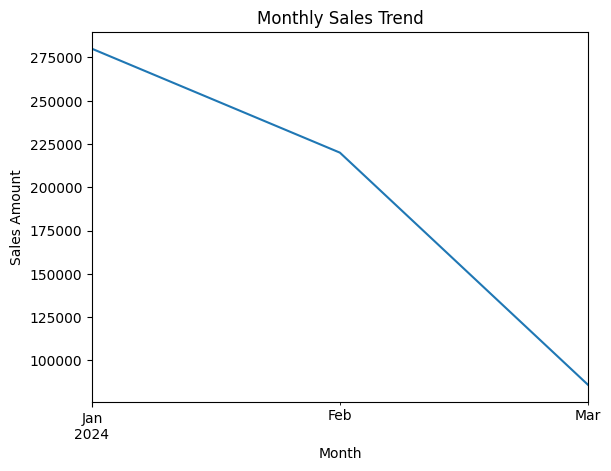

In [ ]:

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()


# Final Business Insights (Expected Discussion)

Students should conclude:

* Electronics generate the highest revenue

* Lahore is the top revenue-generating city

* Sales decrease over months

* Some accessories are low-performing and may need promotions